# Introdução à solução de ODEs com a SciPy

Aqui veremos como utilizar a SciPy para solucionar alguns problemas clássicos de ODE.

A ideia é começar com um problema escalar em que conhecemos a solução analítica, implementar alguns métodos de passo fixo “na mão” e, em seguida, comparar esse comportamento com os integradores adaptativos disponíveis em `scipy.integrate.solve_ivp`.

## Importando as dependências

A primeira coisa a se fazer em qualquer notebook ou código em Python é importar as dependências. Usaremos `numpy` para manipulação vetorial, `matplotlib` para visualização, `pandas` para tabelas-resumo e a `scipy` para os integradores prontos.

In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp

plt.rcParams.update(
    {
        "axes.grid": True,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "figure.figsize": (8, 4.5),
        "font.size": 11,
    }
)

## Um modelo simples: decaimento exponencial

Para ilustrar as principais funções (em especial, a [`scipy.integrate.solve_ivp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)), vamos adotar um modelo simples de decaimento exponencial.

### Formulação do problema-modelo

Considere o problema de valor inicial

$$
\begin{cases}
y'(t) = f(t, y) = -\lambda y(t), \quad t \in [0, T],\\
y(0) = y_0,
\end{cases}
$$

com $\lambda > 0$. A solução analítica é

$$
y(t) = y_0 e^{-\lambda t}.
$$

Esse problema é simples, mas é um ótimo laboratório: ele permite calcular o erro numérico diretamente, verificar ordens de convergência e observar como métodos explícitos e implícitos se comportam quando o passo $h$ muda.

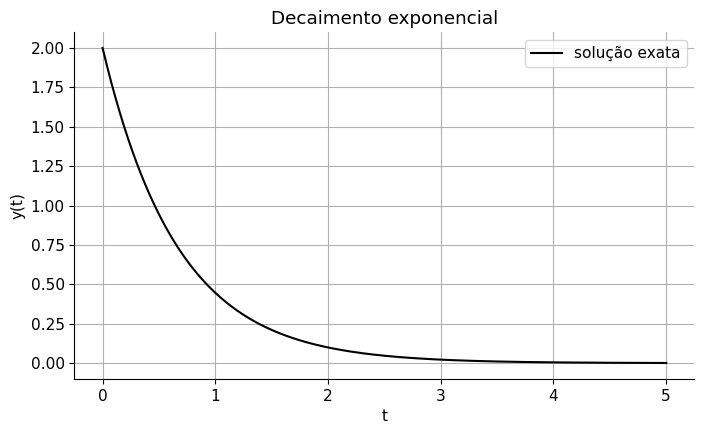

In [2]:
lambda_decay = 1.5
y0_decay = 2.0
T_decay = 5.0


def decaimento_rhs(t, y, lamb):
    return -lamb * y


def solucao_exata_decaimento(t, y0, lamb):
    return y0 * np.exp(-lamb * t)


t_exact_decay = np.linspace(0.0, T_decay, 400)
y_exact_decay = solucao_exata_decaimento(t_exact_decay, y0_decay, lambda_decay)

fig, ax = plt.subplots()
ax.plot(t_exact_decay, y_exact_decay, color="black", label="solução exata")
ax.set_xlabel("t")
ax.set_ylabel("y(t)")
ax.set_title("Decaimento exponencial")
ax.legend()
plt.show()

### Implementações "manuais"

Para ilustrar o que foi visto em aula, vamos solucionar o modelo implementando alguns métodos simples antes de utilizar a `scipy`. Vamos considerar aqui os métodos abaixo:

* Método de Euler Explícito;
* Método de Euler Implícito;
* Método de Crank-Nicolson;
* Método de Runge-Kutta de 4ª ordem;
* Método de Adams-Bashforth de 2ª ordem;
* Método de Adams-Moulton de 2ª ordem.

Vamos considerar também uma solução analítica conhecida do problema e avaliar a taxa de convergência de cada método.

Em uma malha $0=t_0<t_1<\cdots<t_N=T$, com $h_n=t_{n+1}-t_n$, os métodos podem ser escritos como atualizações de $y_n \approx y(t_n)$.

Para o problema linear $y'=-\lambda y$, os métodos implícitos abaixo podem ser resolvidos sem iteração não linear:

$$
\begin{aligned}
\text{Euler explícito:}\quad & y_{n+1}=y_n+h f(t_n,y_n),\\
\text{Euler implícito:}\quad & y_{n+1}=\frac{y_n}{1+h\lambda},\\
\text{Crank-Nicolson:}\quad & y_{n+1}=\frac{1-\frac{h\lambda}{2}}{1+\frac{h\lambda}{2}}y_n,\\
\text{AB2:}\quad & y_{n+1}=y_n+h\left(\frac{3}{2}f_n-\frac{1}{2}f_{n-1}\right),\\
\text{AM2:}\quad & y_{n+1}=y_n+\frac{h}{2}\left(f_{n+1}+f_n\right).
\end{aligned}
$$

O método de Runge-Kutta clássico de quarta ordem usa quatro avaliações intermediárias do campo vetorial:

$$
\begin{aligned}
k_1 &= f(t_n,y_n),\\
k_2 &= f\left(t_n+\frac{h}{2},\,y_n+\frac{h}{2}k_1\right),\\
k_3 &= f\left(t_n+\frac{h}{2},\,y_n+\frac{h}{2}k_2\right),\\
k_4 &= f(t_n+h,\,y_n+h k_3),\\
y_{n+1} &= y_n+\frac{h}{6}\left(k_1+2k_2+2k_3+k_4\right).
\end{aligned}
$$

O método AM2 acima é o método trapezoidal implícito. Para este problema linear, ele coincide com Crank-Nicolson. Já o Adams-Bashforth de 2 passos precisa de um valor inicial adicional; aqui usaremos um único passo de RK4 para obter $y_1$.

Uma observação de nomenclatura: a fórmula

$$
y_{n+1}=y_n+h\left(\frac{5}{12}f_{n+1}+\frac{2}{3}f_n-\frac{1}{12}f_{n-1}\right)
$$

é um método de Adams-Moulton de 2 passos, mas tem ordem 3. Portanto, se usarmos essa fórmula, a ordem estimada deve ficar próxima de 3, não de 2. Aqui queremos o AM2 no sentido de método de segunda ordem.

In [3]:
def euler_explicito(f, t, y0, args=()):
    y0 = np.asarray(y0, dtype=float)
    y = np.empty((len(t), y0.size), dtype=float)
    y[0] = y0

    for n in range(len(t) - 1):
        h = t[n + 1] - t[n]
        y[n + 1] = y[n] + h * np.asarray(f(t[n], y[n], *args), dtype=float)

    return y.squeeze()


def rk4_step(f, t_n, y_n, h, args=()):
    k1 = np.asarray(f(t_n, y_n, *args), dtype=float)
    k2 = np.asarray(f(t_n + 0.5 * h, y_n + 0.5 * h * k1, *args), dtype=float)
    k3 = np.asarray(f(t_n + 0.5 * h, y_n + 0.5 * h * k2, *args), dtype=float)
    k4 = np.asarray(f(t_n + h, y_n + h * k3, *args), dtype=float)
    return y_n + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


def rk4(f, t, y0, args=()):
    y0 = np.asarray(y0, dtype=float)
    y = np.empty((len(t), y0.size), dtype=float)
    y[0] = y0

    for n in range(len(t) - 1):
        h = t[n + 1] - t[n]
        y[n + 1] = rk4_step(f, t[n], y[n], h, args=args)

    return y.squeeze()


def euler_implicito_decaimento(t, y0, lamb):
    y = np.empty(len(t), dtype=float)
    y[0] = y0

    for n in range(len(t) - 1):
        h = t[n + 1] - t[n]
        y[n + 1] = y[n] / (1.0 + h * lamb)

    return y


def crank_nicolson_decaimento(t, y0, lamb):
    y = np.empty(len(t), dtype=float)
    y[0] = y0

    for n in range(len(t) - 1):
        h = t[n + 1] - t[n]
        y[n + 1] = ((1.0 - 0.5 * h * lamb) / (1.0 + 0.5 * h * lamb)) * y[n]

    return y


def adams_bashforth_2(f, t, y0, args=()):
    y0 = np.asarray(y0, dtype=float)
    y = np.empty((len(t), y0.size), dtype=float)
    y[0] = y0

    h0 = t[1] - t[0]
    y[1] = rk4_step(f, t[0], y[0], h0, args=args)

    for n in range(1, len(t) - 1):
        h = t[n + 1] - t[n]
        f_n = np.asarray(f(t[n], y[n], *args), dtype=float)
        f_nm1 = np.asarray(f(t[n - 1], y[n - 1], *args), dtype=float)
        y[n + 1] = y[n] + h * (1.5 * f_n - 0.5 * f_nm1)

    return y.squeeze()


def adams_moulton_2_decaimento(t, y0, lamb):
    y = np.empty(len(t), dtype=float)
    y[0] = y0

    for n in range(len(t) - 1):
        h = t[n + 1] - t[n]
        y[n + 1] = ((1.0 - 0.5 * h * lamb) / (1.0 + 0.5 * h * lamb)) * y[n]

    return y

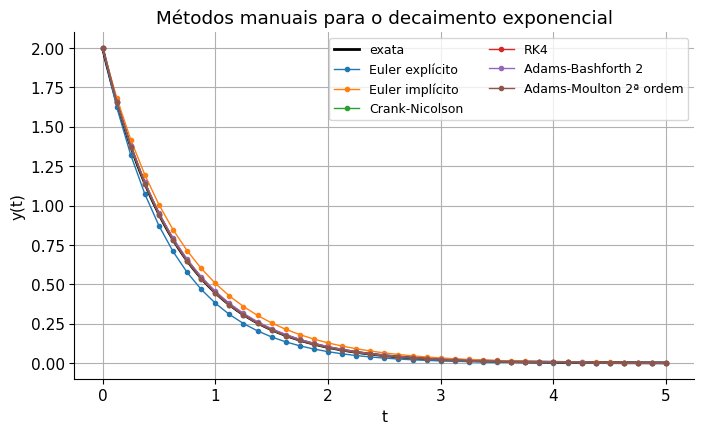

In [4]:
t_decay = np.linspace(0.0, T_decay, 41)
y_exact_on_grid = solucao_exata_decaimento(t_decay, y0_decay, lambda_decay)

manual_decay_solutions = {
    "Euler explícito": euler_explicito(
        decaimento_rhs, t_decay, [y0_decay], args=(lambda_decay,)
    ),
    "Euler implícito": euler_implicito_decaimento(t_decay, y0_decay, lambda_decay),
    "Crank-Nicolson": crank_nicolson_decaimento(t_decay, y0_decay, lambda_decay),
    "RK4": rk4(decaimento_rhs, t_decay, [y0_decay], args=(lambda_decay,)),
    "Adams-Bashforth 2": adams_bashforth_2(
        decaimento_rhs, t_decay, [y0_decay], args=(lambda_decay,)
    ),
    "Adams-Moulton 2ª ordem": adams_moulton_2_decaimento(
        t_decay, y0_decay, lambda_decay
    ),
}

fig, ax = plt.subplots()
ax.plot(t_exact_decay, y_exact_decay, color="black", linewidth=2.0, label="exata")

for method_name, y_num in manual_decay_solutions.items():
    ax.plot(t_decay, y_num, marker="o", markersize=3, linewidth=1.0, label=method_name)

ax.set_xlabel("t")
ax.set_ylabel("y(t)")
ax.set_title("Métodos manuais para o decaimento exponencial")
ax.legend(ncol=2, fontsize=9)
plt.show()

Para estimar as taxas de convergência, precisamos escolher uma medida de erro. Os resultados teóricos de métodos para problemas de valor inicial são geralmente enunciados em termos do erro global no grid temporal,

$$
\max_{0 \leq n \leq N}\|y_n-y(t_n)\|,
$$

em alguma norma para o vetor de estado. No caso escalar, isso vira simplesmente

$$
\max_{0 \leq n \leq N}|y_n-y(t_n)|.
$$

Essa é a escolha adotada aqui. Ela é conservadora, fácil de interpretar e evita que erros grandes em poucos instantes sejam “diluídos”, como poderia acontecer em uma norma discreta do tipo $L^2$ no tempo. Para problemas de dimensão finita, trocar a norma do vetor de estado muda constantes, mas não deve mudar a ordem observada no regime assintótico.

In [5]:
def erro_maximo(y_num, y_ref):
    return np.max(np.abs(np.asarray(y_num) - np.asarray(y_ref)))


decay_methods = {
    "Euler explícito": lambda t: euler_explicito(
        decaimento_rhs, t, [y0_decay], args=(lambda_decay,)
    ),
    "Euler implícito": lambda t: euler_implicito_decaimento(t, y0_decay, lambda_decay),
    "Crank-Nicolson": lambda t: crank_nicolson_decaimento(t, y0_decay, lambda_decay),
    "RK4": lambda t: rk4(decaimento_rhs, t, [y0_decay], args=(lambda_decay,)),
    "Adams-Bashforth 2": lambda t: adams_bashforth_2(
        decaimento_rhs, t, [y0_decay], args=(lambda_decay,)
    ),
    "Adams-Moulton 2ª ordem": lambda t: adams_moulton_2_decaimento(
        t, y0_decay, lambda_decay
    ),
}

convergence_rows = []
n_steps_values = np.array([20, 40, 80, 160, 320, 640])

for n_steps in n_steps_values:
    t_grid = np.linspace(0.0, T_decay, n_steps + 1)
    h = t_grid[1] - t_grid[0]
    y_ref = solucao_exata_decaimento(t_grid, y0_decay, lambda_decay)

    for method_name, method in decay_methods.items():
        y_num = method(t_grid)
        convergence_rows.append(
            {
                "método": method_name,
                "N": n_steps,
                "h": h,
                "erro máximo": erro_maximo(y_num, y_ref),
            }
        )

convergence_decay = pd.DataFrame(convergence_rows)

order_rows = []
for method_name, group in convergence_decay.groupby("método", sort=False):
    slope, intercept = np.polyfit(
        np.log(group["h"]), np.log(group["erro máximo"]), deg=1
    )
    order_rows.append({"método": method_name, "ordem estimada": slope})

convergence_orders = pd.DataFrame(order_rows)
convergence_orders

,método,ordem estimada
0,Euler explícito,1.043981
1,Euler implícito,0.963366
2,Crank-Nicolson,2.001779
3,RK4,4.079506
4,Adams-Bashforth 2,1.957198
5,Adams-Moulton 2ª ordem,2.001779


A tabela acima resume a ordem de convergência observada. Como esperado, Euler explícito e Euler implícito aparecem como métodos de primeira ordem: ao reduzir $h$ pela metade, o erro cai aproximadamente por um fator $2$. Crank-Nicolson, Adams-Bashforth de 2 passos e Adams-Moulton de 2ª ordem aparecem como métodos de segunda ordem, enquanto RK4 apresenta ordem próxima de quatro.

Pequenas diferenças em relação às ordens teóricas são normais, pois estamos estimando a inclinação por regressão em uma faixa finita de passos. Se $h$ for grande demais, o regime assintótico ainda pode não ter sido atingido; se $h$ for pequeno demais, erros de arredondamento começam a aparecer.

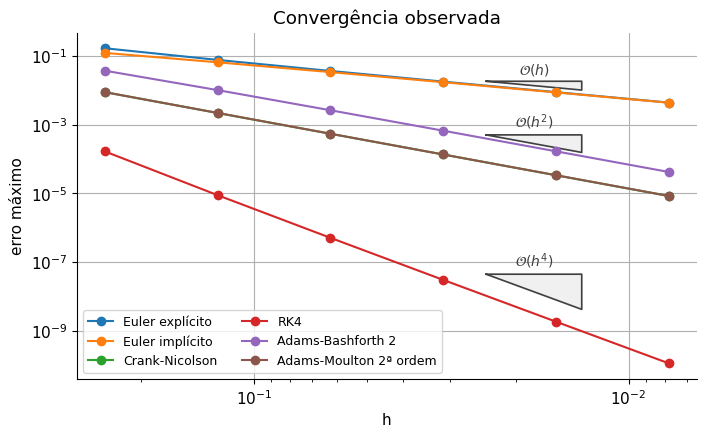

In [6]:
def add_convergence_triangle(ax, x_left, y_left, order, factor=2.0, color="0.25"):
    x_right = x_left / factor
    y_right = y_left / factor**order
    label = r"$\mathcal{O}(h)$" if order == 1 else rf"$\mathcal{{O}}(h^{order})$"

    ax.fill(
        [x_left, x_right, x_right],
        [y_left, y_left, y_right],
        facecolor=color,
        edgecolor=color,
        alpha=0.08,
        linewidth=1.2,
        zorder=1,
    )
    ax.plot(
        [x_left, x_right, x_right, x_left],
        [y_left, y_left, y_right, y_left],
        color=color,
        linewidth=1.2,
        zorder=1.5,
    )
    ax.text(
        np.sqrt(x_left * x_right),
        y_left * 1.25,
        label,
        ha="center",
        va="bottom",
        color=color,
        fontsize=10,
        zorder=4,
    )


fig, ax = plt.subplots()

for method_name, group in convergence_decay.groupby("método", sort=False):
    ax.loglog(group["h"], group["erro máximo"], marker="o", label=method_name, zorder=3)

add_convergence_triangle(ax, x_left=0.024, y_left=1.8e-2, order=1, factor=1.8)
add_convergence_triangle(ax, x_left=0.024, y_left=5.0e-4, order=2, factor=1.8)
add_convergence_triangle(ax, x_left=0.024, y_left=4.5e-8, order=4, factor=1.8)

ax.invert_xaxis()
ax.set_xlabel("h")
ax.set_ylabel("erro máximo")
ax.set_title("Convergência observada")
ax.legend(loc="lower left", ncol=2, fontsize=9)
plt.show()

No gráfico em escala log-log, a inclinação de cada curva corresponde à ordem do método. Curvas mais inclinadas descem mais rapidamente quando refinamos a malha, isto é, quando diminuímos $h$. Essa é uma das formas mais úteis de verificar empiricamente se uma implementação está coerente com a teoria.

Os triângulos de convergência são referências visuais de inclinação. Um triângulo marcado como $\mathcal{O}(h^p)$ indica que, ao reduzir $h$ por um fator fixo, o erro deve cair proporcionalmente a esse fator elevado a $p$. Assim, curvas paralelas ao triângulo $\mathcal{O}(h^2)$ têm comportamento de segunda ordem, enquanto curvas paralelas ao triângulo $\mathcal{O}(h^4)$ têm comportamento de quarta ordem.

Observe também que um método de ordem maior não é automaticamente “melhor” para qualquer passo: para passos muito grosseiros, constantes de erro e efeitos de estabilidade também importam. A ordem descreve principalmente o comportamento quando $h \to 0$.

### Solucionando com a `scipy`

Agora, vamos ver como seria fazer com uma ferramenta pronta, como faríamos em um problema “real”. Vamos considerar os seguintes métodos de `scipy.integrate.solve_ivp`, com uma breve explicação seguida de como utilizar:

* `RK45`;
* `Radau` (Runge-Kutta implícito de ordem 5);
* `BDF`;
* `LSODA`.

A interface básica é

```python
sol = sp.integrate.solve_ivp(fun, t_span, y0, method=..., t_eval=..., rtol=..., atol=...)
```

em que `fun(t, y, *args)` define o campo vetorial, `t_span=(t0, tf)` é o intervalo de integração e `y0` é sempre tratado como vetor, mesmo quando o problema é escalar.

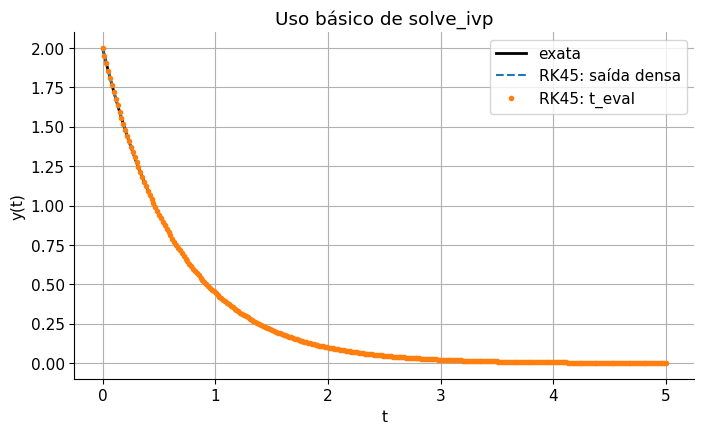

(True,
 'The solver successfully reached the end of the integration interval.',
 452)

In [7]:
t_eval_decay = np.linspace(0.0, T_decay, 300)

sol_decay_rk45 = sp.integrate.solve_ivp(
    decaimento_rhs,
    t_span=(0.0, T_decay),
    y0=[y0_decay],
    args=(lambda_decay,),
    method="RK45",
    t_eval=t_eval_decay,
    dense_output=True,
    rtol=1e-8,
    atol=1e-10,
)

y_scipy_decay = sol_decay_rk45.y[0]
y_dense_decay = sol_decay_rk45.sol(t_exact_decay)[0]

fig, ax = plt.subplots()
ax.plot(t_exact_decay, y_exact_decay, color="black", linewidth=2.0, label="exata")
ax.plot(t_exact_decay, y_dense_decay, "--", label="RK45: saída densa")
ax.plot(t_eval_decay, y_scipy_decay, "o", markersize=3, label="RK45: t_eval")
ax.set_xlabel("t")
ax.set_ylabel("y(t)")
ax.set_title("Uso básico de solve_ivp")
ax.legend()
plt.show()

sol_decay_rk45.success, sol_decay_rk45.message, sol_decay_rk45.nfev

A tupla retornada no final da célula confirma se a integração foi bem-sucedida, mostra a mensagem do solver e informa quantas avaliações de $f(t,y)$ foram usadas. Mesmo especificando `t_eval`, o `RK45` não é obrigado a usar esses pontos como passos internos: ele escolhe passos adaptativos e interpola a solução nos tempos pedidos.

A curva de saída densa (`dense_output=True`) representa essa interpolação contínua construída pelo método. Ela é útil quando queremos consultar a solução em tempos que não foram previamente listados em `t_eval`.

Interpretação rápida dos métodos:

* `RK45`: método explícito de Runge-Kutta adaptativo, indicado como primeira tentativa para problemas não rígidos.
* `Radau`: método implícito de Runge-Kutta, geralmente mais robusto para problemas rígidos.
* `BDF`: família de fórmulas de diferenciação regressiva, também voltada a problemas rígidos.
* `LSODA`: alterna automaticamente entre métodos do tipo Adams e BDF, tentando detectar rigidez durante a integração.

Os parâmetros `rtol` e `atol` controlam a tolerância do erro local. Em termos práticos, diminuir essas tolerâncias tende a aumentar o custo, mas melhora a precisão até o limite em que erros de arredondamento e interpolação passam a dominar.

In [8]:
scipy_methods = ["RK45", "Radau", "BDF", "LSODA"]


def comparar_scipy_decaimento(methods, repeat=10):
    rows = []
    solutions = {}

    for method in methods:
        times = []
        solution = None

        for _ in range(repeat):
            tic = perf_counter()
            solution = sp.integrate.solve_ivp(
                decaimento_rhs,
                t_span=(0.0, T_decay),
                y0=[y0_decay],
                args=(lambda_decay,),
                method=method,
                t_eval=t_eval_decay,
                rtol=1e-8,
                atol=1e-10,
            )
            times.append(perf_counter() - tic)

        solutions[method] = solution
        y_ref = solucao_exata_decaimento(solution.t, y0_decay, lambda_decay)
        rows.append(
            {
                "método": method,
                "sucesso": solution.success,
                "nfev": solution.nfev,
                "njev": getattr(solution, "njev", 0),
                "nlu": getattr(solution, "nlu", 0),
                "erro máximo": erro_maximo(solution.y[0], y_ref),
                "tempo mediano (ms)": 1e3 * np.median(times),
            }
        )

    return pd.DataFrame(rows), solutions


comparacao_scipy_decay, solucoes_scipy_decay = comparar_scipy_decaimento(scipy_methods)
comparacao_scipy_decay

,método,sucesso,nfev,njev,nlu,erro máximo,tempo mediano (ms)
0,RK45,True,452,0,0,4.966980e-09,12.579952
1,Radau,True,1541,2,12,1.982560e-09,96.348873
2,BDF,True,334,1,32,6.586382e-08,49.896091
3,LSODA,True,159,0,0,4.067335e-08,4.110818


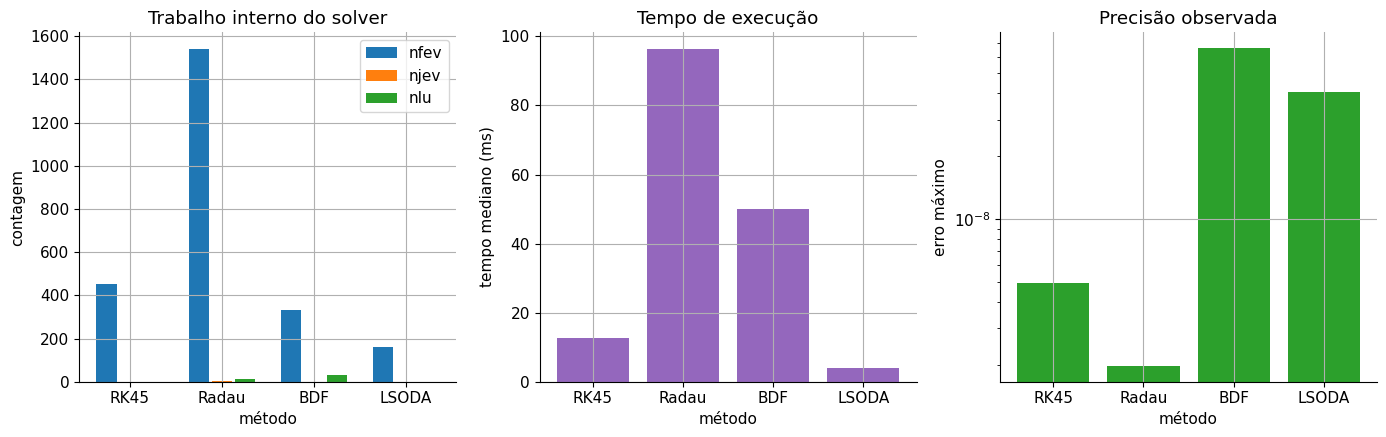

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

methods = comparacao_scipy_decay["método"]
x_positions = np.arange(len(methods))

work_columns = ["nfev", "njev", "nlu"]
work_offsets = np.linspace(-0.25, 0.25, len(work_columns))
bar_width = 0.22

for offset, column in zip(work_offsets, work_columns):
    axes[0].bar(
        x_positions + offset,
        comparacao_scipy_decay[column],
        width=bar_width,
        label=column,
    )

axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(methods)
axes[0].set_ylabel("contagem")
axes[0].set_title("Trabalho interno do solver")
axes[0].legend()

axes[1].bar(methods, comparacao_scipy_decay["tempo mediano (ms)"], color="tab:purple")
axes[1].set_ylabel("tempo mediano (ms)")
axes[1].set_title("Tempo de execução")

axes[2].bar(methods, comparacao_scipy_decay["erro máximo"], color="tab:green")
axes[2].set_yscale("log")
axes[2].set_ylabel("erro máximo")
axes[2].set_title("Precisão observada")

for ax in axes:
    ax.set_xlabel("método")

fig.tight_layout()
plt.show()

Nessa tabela e nos gráficos acima, `nfev` mede quantas vezes o lado direito da ODE foi avaliado. Para métodos implícitos, `njev` e `nlu` indicam, respectivamente, avaliações do Jacobiano e fatorações lineares, que são operações mais caras e aparecem porque esses métodos resolvem sistemas algébricos internamente.

O primeiro gráfico separa os contadores de trabalho interno; o segundo mostra o tempo mediano medido diretamente; e o terceiro mostra o erro máximo em escala logarítmica. A escala log no erro é útil porque as diferenças podem ocorrer em ordens de grandeza, mesmo quando visualmente todas as soluções parecem sobrepostas.

Portanto, a comparação de tempo deve ser lida junto com esses contadores e com o erro. Em um problema escalar simples, o custo extra dos métodos implícitos tende a não compensar. Em problemas rígidos, porém, esse custo por passo pode valer a pena porque o método consegue dar passos maiores sem perder estabilidade.

### Comparando os métodos da `scipy`

Agora, uma breve comparação dos resultados e também de performance em termos de custo computacional observado. Para integradores adaptativos, o número de avaliações da função (`nfev`), do Jacobiano (`njev`) e de fatorações lineares (`nlu`) costuma ser mais informativo do que apenas contar pontos em `t_eval`, porque os passos internos são escolhidos pelo próprio solver.

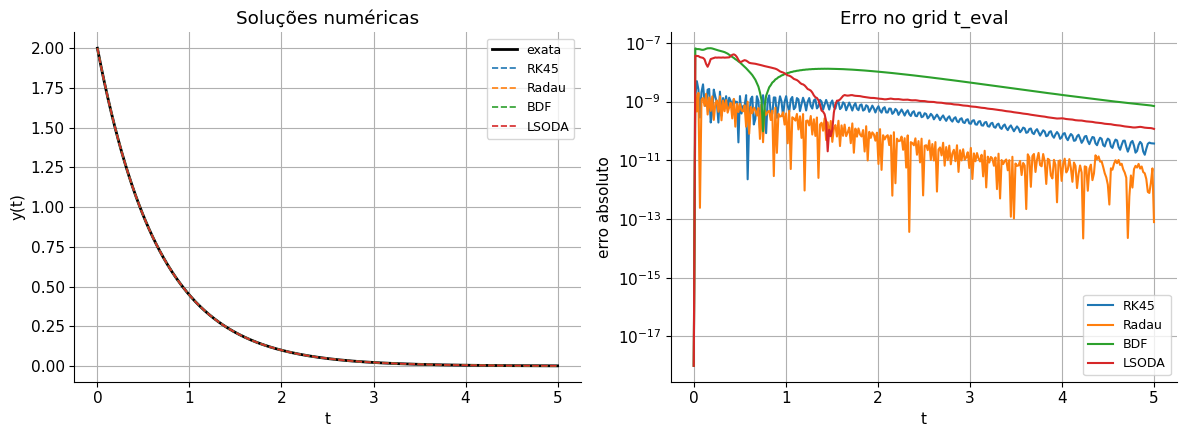

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(t_exact_decay, y_exact_decay, color="black", linewidth=2.0, label="exata")
for method_name, solution in solucoes_scipy_decay.items():
    axes[0].plot(solution.t, solution.y[0], "--", linewidth=1.2, label=method_name)

axes[0].set_xlabel("t")
axes[0].set_ylabel("y(t)")
axes[0].set_title("Soluções numéricas")
axes[0].legend(fontsize=9)

for method_name, solution in solucoes_scipy_decay.items():
    y_ref = solucao_exata_decaimento(solution.t, y0_decay, lambda_decay)
    error = np.maximum(np.abs(solution.y[0] - y_ref), 1e-18)
    axes[1].semilogy(solution.t, error, label=method_name)

axes[1].set_xlabel("t")
axes[1].set_ylabel("erro absoluto")
axes[1].set_title("Erro no grid t_eval")
axes[1].legend(fontsize=9)

fig.tight_layout()

No painel da esquerda, as curvas ficam praticamente sobrepostas à solução exata, então precisamos olhar o painel da direita para enxergar diferenças. O erro absoluto permanece pequeno para todos os métodos com as tolerâncias escolhidas, mas o custo computacional não é o mesmo.

Para esse problema escalar e não rígido, `RK45` normalmente é suficiente. Métodos implícitos como `Radau` e `BDF` têm custo adicional por passo, mas se tornam vantajosos em problemas rígidos, nos quais métodos explícitos precisariam de passos muito pequenos por estabilidade.

## Um modelo não tão simples: Lotka-Volterra

Agora, para exemplificar como devemos fazer para resolver um problema com mais de uma variável de estado, vamos solucionar um problema típico de dinâmica populacional, o modelo de Lotka-Volterra.

### Formulação do problema de valor inicial

O modelo presa-predador clássico é dado por

$$
\begin{aligned}
x'(t) &= \alpha x(t) - \beta x(t)y(t),\\
y'(t) &= \delta x(t)y(t) - \gamma y(t),
\end{aligned}
$$

em que $x(t)$ representa a população de presas e $y(t)$ a população de predadores. Em forma vetorial,

$$
\mathbf{z}'(t)=\mathbf{f}(t,\mathbf{z}),
\quad
\mathbf{z}(0)=\begin{bmatrix}x_0\\ y_0\end{bmatrix}.
$$

O ponto importante para a implementação é que `solve_ivp` sempre espera que a função retorne um vetor com o mesmo tamanho de `y0`.

Antes de simular, vale identificar os estados estacionários do modelo. Um estado estacionário, ou equilíbrio, é um ponto em que as derivadas são nulas. Nesse caso, o sistema fica “parado” se começar exatamente ali:

$$
x' = 0
\quad\text{e}\quad
y' = 0.
$$

Para Lotka-Volterra, podemos fatorar as equações como

$$
x' = x(\alpha-\beta y),
\qquad
y' = y(\delta x-\gamma).
$$

Assim, há duas possibilidades relevantes no quadrante não negativo:

* se $x=0$ e $y=0$, temos o equilíbrio na origem;
* se $x>0$ e $y>0$, precisamos ter $\alpha-\beta y=0$ e $\delta x-\gamma=0$.

Da segunda condição obtemos

$$
y^* = \frac{\alpha}{\beta},
\qquad
x^* = \frac{\gamma}{\delta}.
$$

Esse segundo ponto é chamado de equilíbrio de coexistência porque presas e predadores têm valores positivos simultaneamente. A palavra “coexistência” não significa que as populações ficam sempre constantes em qualquer simulação; significa apenas que existe um estado estacionário positivo em que as duas espécies podem coexistir com taxas instantâneas de crescimento iguais a zero.

In [11]:
lv_params = (1.1, 0.4, 0.1, 0.4)
alpha, beta, delta, gamma = lv_params
z0_lv = np.array([10.0, 5.0])
T_lv = 30.0
t_lv = np.linspace(0.0, T_lv, 1501)


def lotka_volterra(t, state, alpha, beta, delta, gamma):
    prey, predator = state
    return np.array(
        [
            alpha * prey - beta * prey * predator,
            delta * prey * predator - gamma * predator,
        ],
        dtype=float,
    )


def jac_lotka_volterra(state, alpha, beta, delta, gamma):
    prey, predator = state
    return np.array(
        [
            [alpha - beta * predator, -beta * prey],
            [delta * predator, delta * prey - gamma],
        ],
        dtype=float,
    )


coexistence_lv = np.array([gamma / delta, alpha / beta])
pd.DataFrame(
    {
        "parâmetro": ["alpha", "beta", "delta", "gamma", "x0", "y0", "x*", "y*"],
        "valor": [
            alpha,
            beta,
            delta,
            gamma,
            z0_lv[0],
            z0_lv[1],
            coexistence_lv[0],
            coexistence_lv[1],
        ],
    }
)

,parâmetro,valor
0,alpha,1.10
1,beta,0.40
2,delta,0.10
3,gamma,0.40
4,x0,10.00
5,y0,5.00
6,x*,4.00
7,y*,2.75


A tabela fixa os parâmetros usados na simulação e mostra também o equilíbrio de coexistência $(x^*,y^*)=(\gamma/\delta,\alpha/\beta)$. Esse ponto representa uma configuração em que presas e predadores coexistem com derivadas nulas: se o sistema começasse exatamente nesse ponto, permaneceria nele.

Fora do equilíbrio, o modelo descreve um ciclo qualitativo: muitas presas favorecem o crescimento dos predadores; muitos predadores reduzem a população de presas; poucas presas reduzem a população de predadores; e poucos predadores permitem que as presas cresçam novamente.

### Implementações manuais

Vamos agora dar uma olhada rápida em como seria uma implementação manual dos métodos de Euler Explícito e Implícito para o problema de LV. Como exercício, fica recomendada a implementação de Crank-Nicolson e RK4.

No Euler implícito, agora aparece um sistema não linear em cada passo:

$$
\mathbf{z}_{n+1}-\mathbf{z}_n-h\mathbf{f}(t_{n+1},\mathbf{z}_{n+1})=\mathbf{0}.
$$

Resolveremos esse sistema por Newton usando o Jacobiano analítico do campo vetorial.

Também vamos monitorar um invariante do modelo contínuo.

**Invariante.** Um invariante é uma quantidade calculada a partir do estado do sistema que permanece constante ao longo da solução exata. Em outras palavras, embora $x(t)$ e $y(t)$ mudem com o tempo, uma combinação específica dessas variáveis pode manter sempre o mesmo valor.

Para este modelo, uma escolha possível é

$$
H(x,y)=\delta x-\gamma\ln(x)+\beta y-\alpha\ln(y),
\qquad x>0,\ y>0.
$$

Para verificar que $H$ é conservado, basta derivar ao longo da trajetória:

$$
\frac{dH}{dt}
=
\left(\delta-\frac{\gamma}{x}\right)x'
+
\left(\beta-\frac{\alpha}{y}\right)y'
=
0.
$$

Portanto, a solução exata mantém o mesmo valor de $H$ para todo tempo. Na prática, métodos numéricos não preservam exatamente esse valor; por isso, a variação do invariante é um bom diagnóstico do desvio numérico em relação à órbita correta.

In [12]:
def euler_implicito_lotka_volterra(t, z0, params, tol=1e-11, max_iter=20):
    z = np.empty((len(t), 2), dtype=float)
    z[0] = np.asarray(z0, dtype=float)

    for n in range(len(t) - 1):
        h = t[n + 1] - t[n]
        z_next = z[n] + h * lotka_volterra(t[n], z[n], *params)

        for _ in range(max_iter):
            residual = z_next - z[n] - h * lotka_volterra(t[n + 1], z_next, *params)
            jacobian = np.eye(2) - h * jac_lotka_volterra(z_next, *params)
            correction = np.linalg.solve(jacobian, -residual)
            z_next = z_next + correction

            if np.linalg.norm(correction, ord=np.inf) < tol:
                break
        else:
            raise RuntimeError(f"Newton não convergiu no passo {n}.")

        z[n + 1] = z_next

    return z


lv_explicit = euler_explicito(lotka_volterra, t_lv, z0_lv, args=lv_params)
lv_implicit = euler_implicito_lotka_volterra(t_lv, z0_lv, lv_params)

,método,variação máxima do invariante
0,Euler explícito,0.123995
1,Euler implícito,0.099535


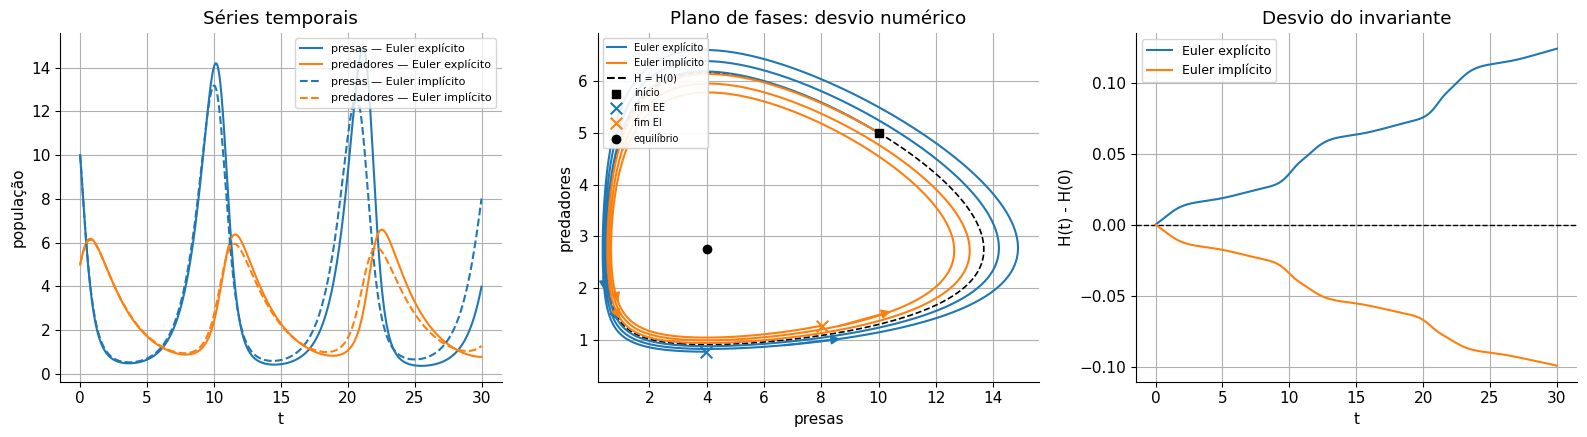

In [13]:
def lv_invariant(states, alpha, beta, delta, gamma):
    states = np.asarray(states, dtype=float)
    prey = states[..., 0]
    predator = states[..., 1]
    return (
        delta * prey - gamma * np.log(prey) + beta * predator - alpha * np.log(predator)
    )


def invariant_variation(states, params):
    invariant = lv_invariant(states, *params)
    return np.max(np.abs(invariant - invariant[0]))


def add_orbit_arrows(
    ax, trajectory, color, positions=(0.18, 0.42, 0.66, 0.88), step=18
):
    trajectory = np.asarray(trajectory, dtype=float)
    max_start = len(trajectory) - step - 1

    for position in positions:
        start = int(position * max_start)
        end = start + step
        ax.annotate(
            "",
            xy=trajectory[end],
            xytext=trajectory[start],
            arrowprops={
                "arrowstyle": "-|>",
                "color": color,
                "lw": 1.4,
                "mutation_scale": 13,
                "shrinkA": 0,
                "shrinkB": 0,
            },
            zorder=4,
        )


explicit_color = "tab:blue"
implicit_color = "tab:orange"
initial_invariant = lv_invariant(z0_lv, *lv_params)
explicit_invariant_drift = lv_invariant(lv_explicit, *lv_params) - initial_invariant
implicit_invariant_drift = lv_invariant(lv_implicit, *lv_params) - initial_invariant

x_phase = np.linspace(
    0.2, 1.05 * max(lv_explicit[:, 0].max(), lv_implicit[:, 0].max()), 250
)
y_phase = np.linspace(
    0.2, 1.05 * max(lv_explicit[:, 1].max(), lv_implicit[:, 1].max()), 250
)
X_phase, Y_phase = np.meshgrid(x_phase, y_phase)
H_phase = lv_invariant(np.stack([X_phase, Y_phase], axis=-1), *lv_params)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(
    t_lv, lv_explicit[:, 0], label="presas — Euler explícito", color="tab:blue"
)
axes[0].plot(
    t_lv, lv_explicit[:, 1], label="predadores — Euler explícito", color="tab:orange"
)
axes[0].plot(
    t_lv, lv_implicit[:, 0], "--", label="presas — Euler implícito", color="tab:blue"
)
axes[0].plot(
    t_lv,
    lv_implicit[:, 1],
    "--",
    label="predadores — Euler implícito",
    color="tab:orange",
)
axes[0].set_xlabel("t")
axes[0].set_ylabel("população")
axes[0].set_title("Séries temporais")
axes[0].legend(fontsize=8)

axes[1].contour(
    X_phase,
    Y_phase,
    H_phase,
    levels=[initial_invariant],
    colors="black",
    linestyles="--",
    linewidths=1.2,
)
axes[1].plot(
    lv_explicit[:, 0], lv_explicit[:, 1], color=explicit_color, label="Euler explícito"
)
axes[1].plot(
    lv_implicit[:, 0], lv_implicit[:, 1], color=implicit_color, label="Euler implícito"
)
add_orbit_arrows(axes[1], lv_explicit, color=explicit_color)
add_orbit_arrows(axes[1], lv_implicit, color=implicit_color)
axes[1].plot([], [], color="black", linestyle="--", label="H = H(0)")
axes[1].scatter(*z0_lv, color="black", marker="s", s=40, zorder=5, label="início")
axes[1].scatter(
    *lv_explicit[-1], color=explicit_color, marker="x", s=70, zorder=5, label="fim EE"
)
axes[1].scatter(
    *lv_implicit[-1], color=implicit_color, marker="x", s=70, zorder=5, label="fim EI"
)
axes[1].scatter(*coexistence_lv, color="black", zorder=5, label="equilíbrio")
axes[1].set_xlabel("presas")
axes[1].set_ylabel("predadores")
axes[1].set_title("Plano de fases: desvio numérico")
axes[1].legend(loc="upper left", fontsize=7, framealpha=0.9)

axes[2].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
axes[2].plot(
    t_lv, explicit_invariant_drift, color=explicit_color, label="Euler explícito"
)
axes[2].plot(
    t_lv, implicit_invariant_drift, color=implicit_color, label="Euler implícito"
)
axes[2].set_xlabel("t")
axes[2].set_ylabel("H(t) - H(0)")
axes[2].set_title("Desvio do invariante")
axes[2].legend(fontsize=9)

fig.tight_layout()

pd.DataFrame(
    {
        "método": ["Euler explícito", "Euler implícito"],
        "variação máxima do invariante": [
            invariant_variation(lv_explicit, lv_params),
            invariant_variation(lv_implicit, lv_params),
        ],
    }
)

O painel temporal mostra as oscilações das duas populações. Já o painel no plano de fases elimina o tempo do eixo horizontal: cada ponto representa um estado completo do sistema, com coordenada horizontal igual ao número de presas e coordenada vertical igual ao número de predadores. Assim, uma curva no plano de fases mostra a sequência de estados visitados pelo sistema. As setas sobre as curvas indicam o sentido em que a trajetória é percorrida à medida que o tempo avança.

A linha tracejada no plano de fases é a curva de nível inicial $H=H(0)$. Para o sistema contínuo, a trajetória exata deveria permanecer sobre essa curva. Os marcadores quadrados indicam o ponto inicial, e os marcadores `x` indicam onde cada método termina no intervalo simulado.

O terceiro painel mostra diretamente o desvio do invariante. Quando $H(t)-H(0)>0$, a trajetória está se deslocando para curvas de nível externas; quando $H(t)-H(0)<0$, ela está se deslocando para curvas internas. Assim, o Euler explícito diverge da órbita correta para fora, enquanto o Euler implícito contrai artificialmente a órbita para dentro.

A diferença entre Euler explícito e Euler implícito aparece justamente nesse desvio numérico. O Euler explícito usa a inclinação calculada no início do passo e tende a avançar “para fora” da órbita correta, introduzindo energia artificial no ciclo presa-predador. O Euler implícito usa a inclinação no final do passo e tende a fazer o contrário: introduz dissipação numérica, puxando a trajetória “para dentro”. Nenhum dos dois preserva a geometria do sistema; eles erram em sentidos opostos porque são métodos de primeira ordem com propriedades de estabilidade diferentes.

### Utilizando a `scipy`

Agora, vamos dar uma olhada em como implementar com a `scipy` quando o problema tem mais de uma variável, como é o caso aqui com o modelo de LV.

A mudança principal em relação ao caso escalar é que `y0` passa a ter duas componentes e `sol.y` terá formato `(2, n_tempos)`: uma linha para cada variável de estado.

,solver,sucesso,nfev,variação máxima do invariante
0,RK45,True,2048,4.785828e-09


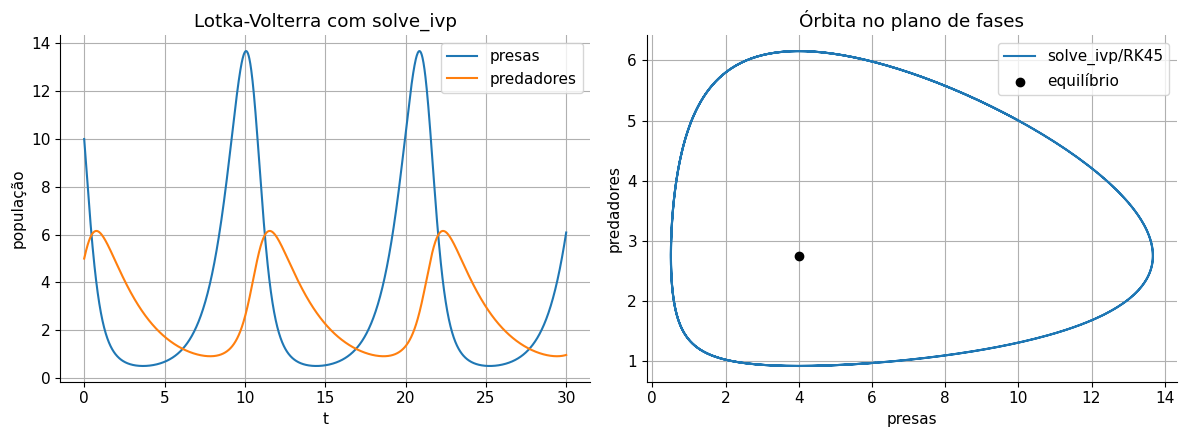

In [14]:
sol_lv = sp.integrate.solve_ivp(
    lotka_volterra,
    t_span=(0.0, T_lv),
    y0=z0_lv,
    args=lv_params,
    method="RK45",
    t_eval=t_lv,
    rtol=1e-9,
    atol=1e-11,
)

lv_scipy = sol_lv.y.T

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(sol_lv.t, lv_scipy[:, 0], label="presas")
axes[0].plot(sol_lv.t, lv_scipy[:, 1], label="predadores")
axes[0].set_xlabel("t")
axes[0].set_ylabel("população")
axes[0].set_title("Lotka-Volterra com solve_ivp")
axes[0].legend()

axes[1].plot(lv_scipy[:, 0], lv_scipy[:, 1], label="solve_ivp/RK45")
axes[1].scatter(*coexistence_lv, color="black", zorder=3, label="equilíbrio")
axes[1].set_xlabel("presas")
axes[1].set_ylabel("predadores")
axes[1].set_title("Órbita no plano de fases")
axes[1].legend()

fig.tight_layout()

pd.DataFrame(
    {
        "solver": ["RK45"],
        "sucesso": [sol_lv.success],
        "nfev": [sol_lv.nfev],
        "variação máxima do invariante": [invariant_variation(lv_scipy, lv_params)],
    }
)

Com tolerâncias mais restritivas, o `RK45` adaptativo mantém a trajetória muito mais próxima da órbita esperada. O ponto importante não é que `solve_ivp` “resolva tudo sozinho”, mas que ele controla o erro local e ajusta o passo automaticamente. Quando a dinâmica acelera, o solver pode reduzir o passo; quando a solução varia mais lentamente, pode aumentá-lo.

No plano de fases, a órbita obtida com `solve_ivp` deve ser interpretada como uma curva de estados possíveis do sistema. O fato de a curva permanecer fechada e próxima de si mesma indica que o integrador está respeitando melhor a estrutura qualitativa do modelo.

## Bônus: mapa de fases e estabilidade

Apenas como comentário adicional e final, vamos dar uma olhada em conceitos úteis para sistemas dinâmicos, como o mapa de fases e a estabilidade do sistema.

Os equilíbrios são obtidos resolvendo $\mathbf{f}(\mathbf{z}^*)=0$, isto é, procurando pontos em que o campo vetorial é zero. No modelo de Lotka-Volterra, as equações fatoradas mostram diretamente de onde eles vêm:

$$
x(\alpha-\beta y)=0,
\qquad
y(\delta x-\gamma)=0.
$$

A origem aparece porque $x=0$ e $y=0$ anulam simultaneamente as duas equações. O equilíbrio de coexistência aparece quando buscamos uma solução com $x>0$ e $y>0$; nesse caso, os fatores entre parênteses precisam ser zero, gerando $y^*=\alpha/\beta$ e $x^*=\gamma/\delta$. Portanto, para o modelo de Lotka-Volterra, temos

$$
(x^*,y^*)=(0,0)
\quad\text{e}\quad
(x^*,y^*)=\left(\frac{\gamma}{\delta},\frac{\alpha}{\beta}\right).
$$

A estabilidade local é analisada pelos autovalores do Jacobiano avaliado em cada equilíbrio.

In [15]:
equilibria_lv = {
    "origem": np.array([0.0, 0.0]),
    "coexistência": coexistence_lv,
}

stability_rows = []
for label, point in equilibria_lv.items():
    eigenvalues = np.linalg.eigvals(jac_lotka_volterra(point, *lv_params))
    stability_rows.append(
        {
            "equilíbrio": label,
            "x*": point[0],
            "y*": point[1],
            "autovalores": ", ".join(
                f"{eig.real:+.4f}{eig.imag:+.4f}i" for eig in eigenvalues
            ),
        }
    )

pd.DataFrame(stability_rows)

,equilíbrio,x*,y*,autovalores
0,origem,0.0,0.00,"+1.1000+0.0000i, -0.4000+0.0000i"
1,coexistência,4.0,2.75,"+0.0000+0.6633i, +0.0000-0.6633i"


A origem é um equilíbrio de sela: os autovalores reais têm sinais opostos, o que indica uma direção local de atração e outra de repulsão. Já o equilíbrio de coexistência possui autovalores puramente imaginários no modelo clássico, sinal de comportamento oscilatório na análise linear.

Isso não significa estabilidade assintótica. As trajetórias próximas não convergem para o equilíbrio; elas circulam ao redor dele. Essa distinção é importante: estabilidade, oscilação e convergência são fenômenos relacionados, mas não equivalentes.

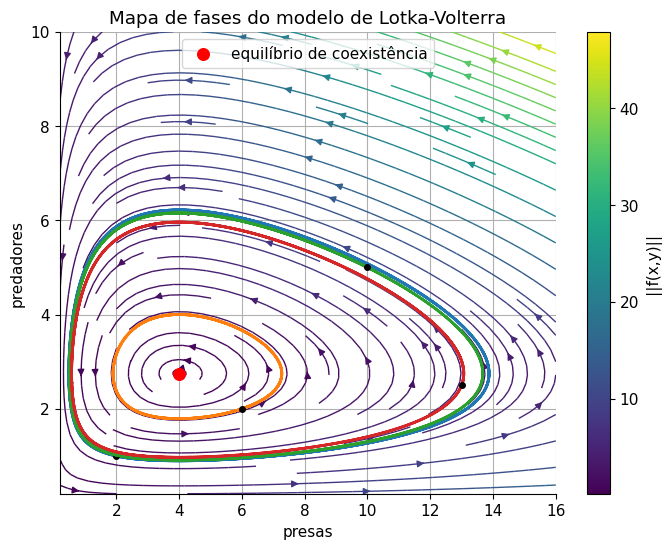

In [16]:
x_grid = np.linspace(0.2, 16.0, 45)
y_grid = np.linspace(0.2, 10.0, 45)
X, Y = np.meshgrid(x_grid, y_grid)
U = alpha * X - beta * X * Y
V = delta * X * Y - gamma * Y
speed = np.hypot(U, V)

initial_conditions = [
    np.array([2.0, 1.0]),
    np.array([6.0, 2.0]),
    np.array([10.0, 5.0]),
    np.array([13.0, 2.5]),
]

fig, ax = plt.subplots(figsize=(8, 6))
stream = ax.streamplot(
    X, Y, U, V, color=speed, cmap="viridis", density=1.2, linewidth=1.0
)
fig.colorbar(stream.lines, ax=ax, label="||f(x,y)||")

for z_initial in initial_conditions:
    sol_phase = sp.integrate.solve_ivp(
        lotka_volterra,
        t_span=(0.0, T_lv),
        y0=z_initial,
        args=lv_params,
        t_eval=np.linspace(0.0, T_lv, 900),
        rtol=1e-9,
        atol=1e-11,
    )
    ax.plot(sol_phase.y[0], sol_phase.y[1], linewidth=2.0)
    ax.plot(z_initial[0], z_initial[1], "o", color="black", markersize=4)

ax.scatter(
    *coexistence_lv, color="red", s=70, zorder=4, label="equilíbrio de coexistência"
)
ax.set_xlabel("presas")
ax.set_ylabel("predadores")
ax.set_title("Mapa de fases do modelo de Lotka-Volterra")
ax.legend()
plt.show()

Como interpretar o mapa de fases:

* Cada ponto do plano representa um possível estado do sistema: $(x,y)=$ (presas, predadores).
* As linhas finas com setas mostram a direção instantânea do campo vetorial $\mathbf{f}(x,y)$. Se o sistema estiver naquele ponto, ele tende a se mover na direção da seta.
* A cor das linhas indica a magnitude $\lVert\mathbf{f}(x,y)\rVert$. Regiões mais intensas correspondem a mudanças mais rápidas das populações.
* Os pontos pretos são condições iniciais. As curvas mais grossas mostram as trajetórias geradas a partir dessas condições.
* O ponto vermelho é o equilíbrio de coexistência. Perto dele, o sistema não converge para o ponto; ele circula ao redor dele.

Para um primeiro contato, a leitura mais importante é: o plano de fases troca a pergunta “como cada população varia no tempo?” pela pergunta “como o estado do sistema se move no espaço das variáveis?”. Essa visão é especialmente útil em sistemas com mais de uma variável, porque revela órbitas, equilíbrios, regiões de atração/repulsão e possíveis efeitos numéricos que seriam menos evidentes olhando apenas séries temporais.

### Exemplo: começando no equilíbrio de coexistência

Agora vamos tomar como condição inicial exatamente o ponto de coexistência,

$$
\mathbf{z}(0)=(x^*,y^*)=\left(\frac{\gamma}{\delta},\frac{\alpha}{\beta}\right).
$$

Como esse ponto satisfaz $\mathbf{f}(\mathbf{z}^*)=\mathbf{0}$, a solução contínua deve permanecer constante:

$$
\mathbf{z}(t)=\mathbf{z}^*, \quad t\geq 0.
$$

Em seguida, perturbamos apenas a primeira componente da condição inicial em 1%, isto é, usamos $x(0)=1{,}01x^*$ e $y(0)=y^*$. A ideia é comparar um equilíbrio exato com uma condição inicial muito próxima dele.

,condição inicial,x0,y0,máx. ||z(t)-z*||
0,coexistência,4.00,2.75,0.00
1,x0 + 1%,4.04,2.75,0.04


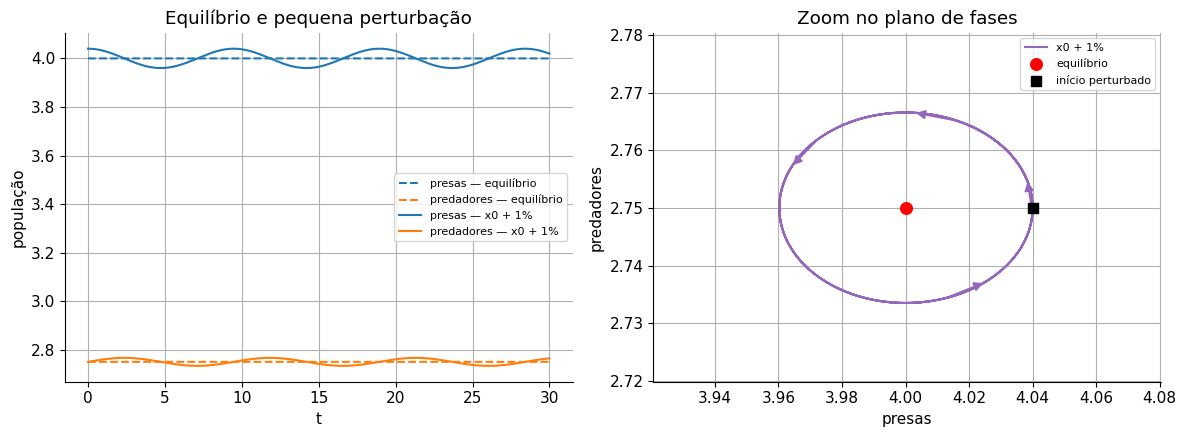

In [17]:
t_bonus = np.linspace(0.0, T_lv, 1200)
z0_coexistence = coexistence_lv.copy()
z0_perturbed = coexistence_lv.copy()
z0_perturbed[0] *= 1.01

sol_coexistence_initial = sp.integrate.solve_ivp(
    lotka_volterra,
    t_span=(0.0, T_lv),
    y0=z0_coexistence,
    args=lv_params,
    method="RK45",
    t_eval=t_bonus,
    rtol=1e-10,
    atol=1e-12,
)

sol_perturbed_initial = sp.integrate.solve_ivp(
    lotka_volterra,
    t_span=(0.0, T_lv),
    y0=z0_perturbed,
    args=lv_params,
    method="RK45",
    t_eval=t_bonus,
    rtol=1e-10,
    atol=1e-12,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(
    sol_coexistence_initial.t,
    sol_coexistence_initial.y[0],
    "--",
    color="tab:blue",
    label="presas — equilíbrio",
)
axes[0].plot(
    sol_coexistence_initial.t,
    sol_coexistence_initial.y[1],
    "--",
    color="tab:orange",
    label="predadores — equilíbrio",
)
axes[0].plot(
    sol_perturbed_initial.t,
    sol_perturbed_initial.y[0],
    color="tab:blue",
    label="presas — x0 + 1%",
)
axes[0].plot(
    sol_perturbed_initial.t,
    sol_perturbed_initial.y[1],
    color="tab:orange",
    label="predadores — x0 + 1%",
)
axes[0].set_xlabel("t")
axes[0].set_ylabel("população")
axes[0].set_title("Equilíbrio e pequena perturbação")
axes[0].legend(fontsize=8)

perturbed_orbit = sol_perturbed_initial.y.T
axes[1].plot(
    perturbed_orbit[:, 0], perturbed_orbit[:, 1], color="tab:purple", label="x0 + 1%"
)
add_orbit_arrows(
    axes[1],
    perturbed_orbit,
    color="tab:purple",
    positions=(0.12, 0.38, 0.64, 0.9),
    step=20,
)
axes[1].scatter(*coexistence_lv, color="red", s=70, zorder=5, label="equilíbrio")
axes[1].scatter(
    *z0_perturbed, color="black", marker="s", s=45, zorder=5, label="início perturbado"
)
axes[1].set_xlabel("presas")
axes[1].set_ylabel("predadores")
axes[1].set_title("Zoom no plano de fases")
axes[1].set_xlim(0.99 * perturbed_orbit[:, 0].min(), 1.01 * perturbed_orbit[:, 0].max())
axes[1].set_ylim(
    0.995 * perturbed_orbit[:, 1].min(), 1.005 * perturbed_orbit[:, 1].max()
)
axes[1].legend(fontsize=8)

fig.tight_layout()

pd.DataFrame(
    {
        "condição inicial": ["coexistência", "x0 + 1%"],
        "x0": [z0_coexistence[0], z0_perturbed[0]],
        "y0": [z0_coexistence[1], z0_perturbed[1]],
        "máx. ||z(t)-z*||": [
            np.max(
                np.linalg.norm(sol_coexistence_initial.y.T - coexistence_lv, axis=1)
            ),
            np.max(np.linalg.norm(sol_perturbed_initial.y.T - coexistence_lv, axis=1)),
        ],
    }
)

Quando começamos exatamente no equilíbrio de coexistência, as duas populações permanecem constantes. Isso é o que esperamos de um equilíbrio: o campo vetorial é nulo naquele ponto.

Ao perturbar apenas $x(0)$ em 1%, a solução deixa de ficar parada e passa a percorrer uma pequena órbita fechada ao redor do equilíbrio. No modelo clássico de Lotka-Volterra, esse equilíbrio é um centro: pequenas perturbações não são amortecidas até o equilíbrio, nem crescem indefinidamente no modelo contínuo ideal; elas geram oscilações ao redor do ponto de coexistência.